In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set project path
PROJECT_PATH = "/content/drive/MyDrive/Project"

Mounted at /content/drive


In [2]:
# Install required libraries
!pip install pymatgen torch torchvision torchaudio torch_geometric
!pip install tqdm

# Imports
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN

from tqdm import tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.3 MB/s eta 0:00:00
  Created

In [3]:
# Load CSV dataset
csv_path = os.path.join(PROJECT_PATH, "Final Dataset.csv")
df = pd.read_csv(csv_path)

print(df.head())
print("Total samples:", len(df))

  mp_material_id   mp_formula spacegroup  spacegroup_number  number of atoms  \
0         mp-331         ScAl       Pm3m                221              2.0   
1      mp-698479     RbTeHOF4         Cc                  9             32.0   
2      mp-549237  Sr2Fe2S2OF2     I4/mmm                139             18.0   
3       mp-13089     Cu2SnTe3       Imm2                 44              6.0   
4       mp-10732       ThTaN3      Pm-3m                221              5.0   

   Band Gap         a         b          c       alpha        beta      gamma  \
0    0.0000  3.370349  3.370349   3.370349   90.000000   90.000000  90.000000   
1    4.8825  8.430517  8.430517  14.075609   85.886490   85.886490  34.382176   
2    1.4677  4.095118  4.096245  18.221803   90.002343   90.003680  89.993481   
3    0.0000  4.409910  6.113668   7.554224  113.869340  106.970766  90.000000   
4    0.0766  4.064437  4.064437   4.064437   90.000000   90.000000  90.000000   

           Z  electronegativity 

In [4]:
# Atomic feature extractor
from pymatgen.core.periodic_table import Element

def get_atom_features(site):
    elem = Element(site.specie.symbol)

    return [
        elem.Z,
        elem.X if elem.X else 0,
        elem.atomic_radius if elem.atomic_radius else 0,
        elem.group if elem.group else 0,
        elem.row if elem.row else 0
    ]

In [5]:
# Gaussian Distance Expansion
class GaussianExpansion:
    def __init__(self, dmin=0, dmax=6, step=0.2):
        self.centers = np.arange(dmin, dmax+step, step)
        self.width = step

    def expand(self, distance):
        return np.exp(-((distance - self.centers) ** 2) / self.width**2)

gaussian = GaussianExpansion()

In [6]:

def build_graph(cif_path, label):
    structure = Structure.from_file(cif_path)
    cnn = CrystalNN()

    node_features = []
    edge_index = []
    edge_attr = []

    # Node features
    for site in structure:
        node_features.append(get_atom_features(site))

    # Edges
    for i, site in enumerate(structure):
        neighbors = cnn.get_nn_info(structure, i)

        for n in neighbors:
            j = n['site_index']
            dist = n['weight']

            edge_index.append([i, j])
            edge_attr.append(gaussian.expand(dist))

    return Data(
        x=torch.tensor(node_features, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        y=torch.tensor([label], dtype=torch.long)
    )

In [7]:

graphs = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    cif_path = os.path.join(PROJECT_PATH, row['cif'])
    label = int(row['label'])

    try:
        graph = build_graph(cif_path, label)
        graphs.append(graph)
    except:
        continue

# Save
torch.save(graphs, os.path.join(PROJECT_PATH, "graphs.pt"))

print("Graphs saved:", len(graphs))

100%|██████████| 7000/7000 [1:09:00<00:00,  1.69it/s]


Graphs saved: 7000


In [8]:

labels = [g.y.item() for g in graphs]

train_idx, temp_idx = train_test_split(
    range(len(graphs)),
    test_size=0.3,
    stratify=labels,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=[labels[i] for i in temp_idx]
)

train_set = [graphs[i] for i in train_idx]
val_set = [graphs[i] for i in val_idx]
test_set = [graphs[i] for i in test_idx]

In [9]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [10]:
# CharlesCGCNN Model
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim):
        super().__init__()

        self.conv1 = GCNConv(node_dim, 128)
        self.conv2 = GCNConv(128, 128)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()

        x = global_mean_pool(x, batch)
        return self.fc(x)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CharlesCGCNN(node_dim=5, edge_dim=len(gaussian.centers)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [12]:
def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [13]:
def evaluate(loader):
    model.eval()

    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)

            prob = torch.softmax(out, dim=1)[:,1]

            y_true += data.y.cpu().numpy().tolist()
            y_pred += out.argmax(dim=1).cpu().numpy().tolist()
            y_prob += prob.cpu().numpy().tolist()

    print(classification_report(y_true, y_pred, digits=3))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))

In [14]:
for epoch in range(30):
    loss = train_epoch(train_loader)
    print(f"Epoch {epoch}: Loss = {loss:.4f}")

Epoch 0: Loss = 0.6397
Epoch 1: Loss = 0.6221
Epoch 2: Loss = 0.6124
Epoch 3: Loss = 0.6038
Epoch 4: Loss = 0.5908
Epoch 5: Loss = 0.5830
Epoch 6: Loss = 0.5784
Epoch 7: Loss = 0.5756
Epoch 8: Loss = 0.5696
Epoch 9: Loss = 0.5657
Epoch 10: Loss = 0.5598
Epoch 11: Loss = 0.5500
Epoch 12: Loss = 0.5513
Epoch 13: Loss = 0.5414
Epoch 14: Loss = 0.5406
Epoch 15: Loss = 0.5311
Epoch 16: Loss = 0.5321
Epoch 17: Loss = 0.5240
Epoch 18: Loss = 0.5278
Epoch 19: Loss = 0.5180
Epoch 20: Loss = 0.5091
Epoch 21: Loss = 0.5112
Epoch 22: Loss = 0.5072
Epoch 23: Loss = 0.5002
Epoch 24: Loss = 0.5025
Epoch 25: Loss = 0.4951
Epoch 26: Loss = 0.5030
Epoch 27: Loss = 0.4894
Epoch 28: Loss = 0.4806
Epoch 29: Loss = 0.4858


In [15]:
print("Train Performance:")
evaluate(train_loader)

print("Validation Performance:")
evaluate(val_loader)

print("Test Performance:")
evaluate(test_loader)

Train Performance:
              precision    recall  f1-score   support

           0      0.840     0.628     0.719      2475
           1      0.698     0.878     0.778      2425

    accuracy                          0.752      4900
   macro avg      0.769     0.753     0.748      4900
weighted avg      0.770     0.752     0.748      4900

ROC-AUC: 0.8583740914297615
Validation Performance:
              precision    recall  f1-score   support

           0      0.826     0.597     0.693       531
           1      0.679     0.871     0.763       519

    accuracy                          0.732      1050
   macro avg      0.752     0.734     0.728      1050
weighted avg      0.753     0.732     0.727      1050

ROC-AUC: 0.8379978881595418
Test Performance:
              precision    recall  f1-score   support

           0      0.810     0.613     0.698       530
           1      0.684     0.854     0.760       520

    accuracy                          0.732      1050
   macro av

In [16]:
# Attention-based CharlesCGCNN
import torch.nn as nn
from torch_geometric.nn import GATConv, global_mean_pool

class CharlesCGCNN_Attention(nn.Module):
    def __init__(self, node_dim):
        super().__init__()

        # Attention layers
        self.gat1 = GATConv(node_dim, 128, heads=4, concat=True)
        self.gat2 = GATConv(128*4, 128, heads=1, concat=True)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, data, return_attention=False):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # First attention layer
        x, attn1 = self.gat1(x, edge_index, return_attention_weights=True)
        x = x.relu()

        # Second attention layer
        x, attn2 = self.gat2(x, edge_index, return_attention_weights=True)
        x = x.relu()

        pooled = global_mean_pool(x, batch)
        out = self.fc(pooled)

        if return_attention:
            return out, (attn1, attn2)
        return out

In [17]:
model = CharlesCGCNN_Attention(node_dim=5).to(device)

In [18]:
def get_attention_sample(data):
    model.eval()
    data = data.to(device)

    out, (attn1, attn2) = model(data, return_attention=True)

    return {
        "prediction": out.argmax(dim=1).item(),
        "prob": torch.softmax(out, dim=1)[0,1].item(),
        "attn1": attn1,
        "attn2": attn2
    }

In [19]:
def node_saliency(data):
    model.eval()
    data = data.to(device)

    data.x.requires_grad = True

    out = model(data)
    pred = out[:,1].sum()

    pred.backward()

    saliency = data.x.grad.abs().sum(dim=1).detach().cpu().numpy()

    return saliency

Prediction: 0
Topological Probability: 0.3223736882209778


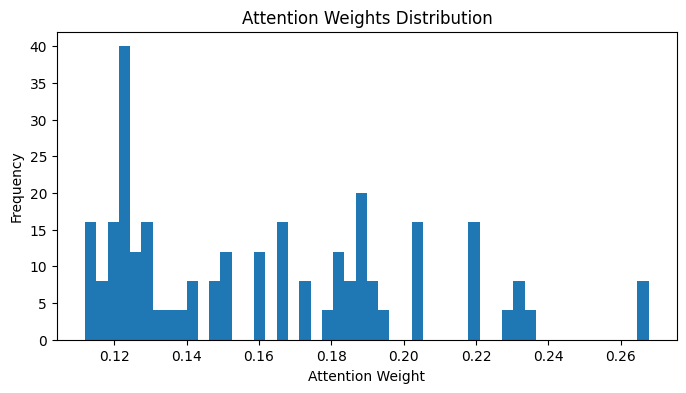

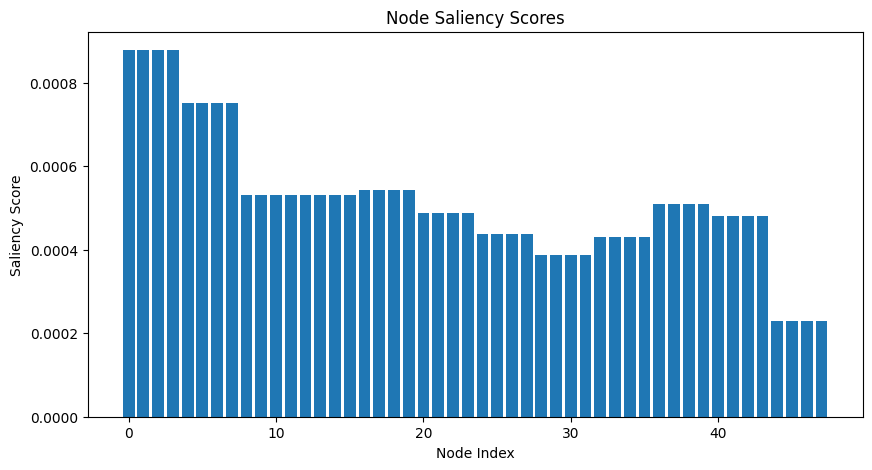

In [22]:
import matplotlib.pyplot as plt

def plot_attention_distribution(attn_tuple):
    """Plots the distribution of attention weights."""
    # attn_tuple is (edge_index, attention_weights)
    if isinstance(attn_tuple, tuple) and len(attn_tuple) == 2:
        _, attention_weights = attn_tuple
        if attention_weights is not None and attention_weights.numel() > 0:
            plt.figure(figsize=(8, 4))
            # Detach the tensor before converting to numpy
            plt.hist(attention_weights.detach().cpu().numpy().flatten(), bins=50)
            plt.title("Attention Weights Distribution")
            plt.xlabel("Attention Weight")
            plt.ylabel("Frequency")
            plt.show()
        else:
            print("No attention weights to plot for attention layer.")
    else:
        print("Invalid attention data format for plotting.")

def plot_node_importance(saliency):
    """Plots node saliency scores as a bar chart."""
    if saliency is not None and len(saliency) > 0:
        plt.figure(figsize=(10, 5))
        plt.bar(range(len(saliency)), saliency)
        plt.title("Node Saliency Scores")
        plt.xlabel("Node Index")
        plt.ylabel("Saliency Score")
        plt.show()
    else:
        print("No saliency data to plot.")

sample = test_set[0]

# Attention
attn_data = get_attention_sample(sample)

print("Prediction:", attn_data["prediction"])
print("Topological Probability:", attn_data["prob"])

# Plot attention
plot_attention_distribution(attn_data["attn2"])

# Node importance
saliency = node_saliency(sample)
plot_node_importance(saliency)